# Drift Detector Comparison: ADWIN vs. DDM vs. EDDM

Compares three concept-drift detectors on the same 3-phase streaming IDS pipeline used in `adaptive_ids_adwin.ipynb` (rehearsal-buffer adaptive Random Forest). ADWIN is the detector already used elsewhere in this project; DDM and EDDM are added here as alternatives, hand-implemented from their original papers (not from a library) so the logic is fully understood and owned.

- **ADWIN** (Bifet & Gavalda, 2007) — adaptive windowing, already implemented in `adaptive_ids_adwin.ipynb`.
- **DDM** (Gama et al., 2004) — monitors the model's running error rate; flags drift when the error rate climbs statistically far above its historical minimum.
- **EDDM** (Baena-Garcia et al., 2006) — monitors the *distance between consecutive errors* instead of the raw error rate, making it more sensitive to slow/gradual drift than DDM.

Everything else (dataset, phases, rehearsal buffer, retrain logic) is held identical across the three runs so any difference in results comes only from the detector.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import copy
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import deque

print('All imports OK')

All imports OK


## 2. Drift Detector Implementations

All three detectors expose the same small interface used by the streaming loop: `add_element(error)` (error = 1.0 if the model got that sample wrong, else 0.0), a `drift_detected` flag checked after each call, and `reset()`.

In [2]:
class ADWIN:
    """
    ADaptive WINdowing drift detector.
    Based on: Bifet & Gavalda (2007) 'Learning from Time-Changing Data with Adaptive Windowing'
    (same implementation as adaptive_ids_adwin.ipynb, copied here so this notebook is self-contained.)
    """

    def __init__(self, delta=0.002):
        self.delta = delta
        self.window = deque()
        self.total  = 0.0
        self.drift_detected = False
        self.n_detections   = 0

    def add_element(self, value):
        self.drift_detected = False
        self.window.append(value)
        self.total += value
        self._check_drift()

    def _check_drift(self):
        n = len(self.window)
        if n < 5:
            return
        window_list = list(self.window)
        total_sum   = self.total
        running_sum = 0.0
        for i in range(1, n):
            running_sum += window_list[i - 1]
            n0 = i
            n1 = n - i
            mean0 = running_sum / n0
            mean1 = (total_sum - running_sum) / n1
            m = 1.0 / (1.0 / n0 + 1.0 / n1)
            eps_cut = np.sqrt((1.0 / (2.0 * m)) * np.log(4.0 * n / self.delta))
            if abs(mean0 - mean1) >= eps_cut:
                for _ in range(i):
                    removed = self.window.popleft()
                    self.total -= removed
                self.drift_detected = True
                self.n_detections  += 1
                return

    def reset(self):
        self.window.clear()
        self.total = 0.0
        self.drift_detected = False

    @property
    def estimation(self):
        return self.total / len(self.window) if self.window else 0.0


print('ADWIN class defined')

ADWIN class defined


In [3]:
class DDM:
    """
    Drift Detection Method.
    Based on: Gama, Medas, Castillo & Rodrigues (2004) 'Learning with Drift Detection'.

    Tracks the running error rate p_i and its standard deviation s_i = sqrt(p_i*(1-p_i)/i).
    Remembers the smallest (p_i + s_i) seen since the last reset (p_min, s_min) -- this is the
    detector's best estimate of the model's true error rate while it was stable.
    Drift is signalled once the current (p_i + s_i) climbs statistically far above that minimum:
    the model is making mistakes more often than its best-known stable rate would predict.
    """

    def __init__(self, warning_level=2.0, drift_level=3.0, min_instances=30):
        self.warning_level = warning_level
        self.drift_level   = drift_level
        self.min_instances = min_instances
        self.reset()

    def reset(self):
        self.i = 1
        self.p_i = 1.0
        self.s_i = 0.0
        self.p_min = float('inf')
        self.s_min = float('inf')
        self.drift_detected  = False
        self.warning_detected = False
        self.n_detections = getattr(self, 'n_detections', 0)

    def add_element(self, value):
        # value: 1.0 if the model was wrong on this sample, 0.0 if correct
        self.drift_detected  = False
        self.warning_detected = False

        self.p_i = self.p_i + (value - self.p_i) / self.i
        self.s_i = np.sqrt(self.p_i * (1 - self.p_i) / self.i)
        self.i += 1

        if self.i < self.min_instances:
            return

        if self.p_i + self.s_i < self.p_min + self.s_min:
            self.p_min = self.p_i
            self.s_min = self.s_i

        if self.p_i + self.s_i > self.p_min + self.drift_level * self.s_min:
            self.drift_detected = True
            self.n_detections += 1
        elif self.p_i + self.s_i > self.p_min + self.warning_level * self.s_min:
            self.warning_detected = True

    @property
    def estimation(self):
        return self.p_i


print('DDM class defined')

DDM class defined


In [4]:
class EDDM:
    """
    Early Drift Detection Method.
    Based on: Baena-Garcia, del Campo-Avila, Fidalgo, Bifet, Gavalda & Morales-Bueno (2006)
    'Early Drift Detection Method'.

    Instead of the raw error rate (DDM), EDDM tracks the running mean distance between two
    consecutive errors (i.e. how many correct predictions typically separate two mistakes) and
    its standard deviation. It remembers the LARGEST (p'_i + 2*s'_i) seen since the last reset --
    the widest, healthiest error-spacing the model has shown. Drift is signalled once that spacing
    shrinks a lot (errors start clustering closer together), which tends to catch slow/gradual
    drift earlier than DDM's raw-error-rate approach.
    """

    def __init__(self, alpha=0.95, beta=0.90, min_num_errors=30):
        self.alpha = alpha
        self.beta = beta
        self.min_num_errors = min_num_errors
        self.reset()

    def reset(self):
        self.n_i = 0                 # samples seen since last reset
        self.num_errors = 0
        self.last_error_pos = None
        self.p_i = 0.0                # running mean distance between errors
        self.s_i = 0.0                # running variance of that distance (for std)
        self.p_max = 0.0
        self.s_max = 0.0
        self.drift_detected  = False
        self.warning_detected = False
        self.n_detections = getattr(self, 'n_detections', 0)

    def add_element(self, value):
        self.drift_detected  = False
        self.warning_detected = False
        self.n_i += 1

        if value != 1.0:
            return  # only errors carry information for EDDM

        self.num_errors += 1
        if self.last_error_pos is None:
            self.last_error_pos = self.n_i
            return

        distance = self.n_i - self.last_error_pos
        self.last_error_pos = self.n_i

        # Welford-style running mean/variance of the error-to-error distance
        old_p = self.p_i
        self.p_i = self.p_i + (distance - self.p_i) / self.num_errors
        self.s_i = self.s_i + (distance - old_p) * (distance - self.p_i)
        std = np.sqrt(self.s_i / self.num_errors) if self.num_errors > 0 else 0.0

        if self.num_errors < self.min_num_errors:
            return

        if self.p_i + 2 * std > self.p_max + 2 * self.s_max:
            self.p_max = self.p_i
            self.s_max = std

        ratio = (self.p_i + 2 * std) / (self.p_max + 2 * self.s_max) if (self.p_max + 2 * self.s_max) > 0 else 1.0

        if ratio < self.beta:
            self.drift_detected = True
            self.n_detections += 1
        elif ratio < self.alpha:
            self.warning_detected = True

    @property
    def estimation(self):
        return self.p_i


print('EDDM class defined')

EDDM class defined


## 3. Build 3-Phase Drift Dataset

Identical to `adaptive_ids_adwin.ipynb`: three phases of attack types, each with a held-out slice never used in streaming/retraining, reserved for a leak-free final evaluation.

In [5]:
DATASET_DIR  = '../datasets/cicids2023/'
SAMPLES_PER_PHASE = 15000
HOLDOUT_FRAC = 0.15

PHASE1_TYPES = ['DDOS-ICMP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-TCP_FLOOD',
                'DDOS-SYN_FLOOD', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD',
                'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-ACK_FRAGMENTATION',
                'DDOS-ICMP_FRAGMENTATION', 'DDOS-UDP_FRAGMENTATION',
                'DDOS-HTTP_FLOOD', 'DDOS-SLOWLORIS', 'BENIGN']

PHASE2_TYPES = ['DOS-UDP_FLOOD', 'DOS-TCP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-HTTP_FLOOD',
                'RECON-HOSTDISCOVERY', 'RECON-PORTSCAN', 'RECON-OSSCAN', 'RECON-PINGSWEEP',
                'MIRAI-GREIP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-UDPPLAIN',
                'VULNERABILITYSCAN', 'BENIGN']

PHASE3_TYPES = ['XSS', 'SQLINJECTION', 'COMMANDINJECTION', 'BROWSERHIJACKING',
                'DNS_SPOOFING', 'MITM-ARPSPOOFING', 'BACKDOOR_MALWARE',
                'DICTIONARYBRUTEFORCE', 'BENIGN']

def collect_phase_data(label_set, n_samples):
    csv_files = sorted(glob.glob(os.path.join(DATASET_DIR, 'Merged*.csv')))
    chunks = []
    collected = 0
    for f in csv_files:
        df = pd.read_csv(f).dropna()
        df = df[df['Label'].isin(label_set)]
        if len(df) == 0:
            continue
        need = n_samples - collected
        chunks.append(df.iloc[:need])
        collected += len(chunks[-1])
        if collected >= n_samples:
            break
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

def split_stream_holdout(df, frac=HOLDOUT_FRAC, seed=42, min_class_size=5):
    holdout_idx = []
    for _, group in df.groupby('Label'):
        n = len(group)
        n_hold = int(round(n * frac))
        if n < min_class_size or n_hold < 1:
            continue
        holdout_idx.extend(group.sample(n=n_hold, random_state=seed).index)
    holdout_df = df.loc[holdout_idx].reset_index(drop=True)
    stream_df  = df.drop(index=holdout_idx).reset_index(drop=True)
    return stream_df, holdout_df

print('Collecting Phase 1 (DDoS)...')
df_phase1_full = collect_phase_data(PHASE1_TYPES, SAMPLES_PER_PHASE)
df_phase1, df_phase1_holdout = split_stream_holdout(df_phase1_full)
print(f'  Phase 1: {len(df_phase1_full)} samples ({len(df_phase1)} stream / {len(df_phase1_holdout)} holdout), classes: {df_phase1_full["Label"].nunique()}')

print('Collecting Phase 2 (DoS + Recon + Mirai)...')
df_phase2_full = collect_phase_data(PHASE2_TYPES, SAMPLES_PER_PHASE)
df_phase2, df_phase2_holdout = split_stream_holdout(df_phase2_full)
print(f'  Phase 2: {len(df_phase2_full)} samples ({len(df_phase2)} stream / {len(df_phase2_holdout)} holdout), classes: {df_phase2_full["Label"].nunique()}')

print('Collecting Phase 3 (Web/Application Attacks)...')
df_phase3_full = collect_phase_data(PHASE3_TYPES, SAMPLES_PER_PHASE)
df_phase3, df_phase3_holdout = split_stream_holdout(df_phase3_full)
print(f'  Phase 3: {len(df_phase3_full)} samples ({len(df_phase3)} stream / {len(df_phase3_holdout)} holdout), classes: {df_phase3_full["Label"].nunique()}')

all_labels = pd.concat([df_phase1_full['Label'], df_phase2_full['Label'], df_phase3_full['Label']])
encoder = LabelEncoder()
encoder.fit(all_labels)
print(f'\nTotal classes across all phases: {len(encoder.classes_)}')

  Phase 1: 15000 samples (12751 stream / 2249 holdout), classes: 13


  Phase 2: 15000 samples (12750 stream / 2250 holdout), classes: 13


  Phase 3: 15000 samples (12749 stream / 2251 holdout), classes: 9

Total classes across all phases: 33


## 4. Train Initial Static Model on Phase 1

In [6]:
feature_cols = [c for c in df_phase1.columns if c != 'Label']

X1 = df_phase1[feature_cols].values
y1 = encoder.transform(df_phase1['Label'])

INIT_SPLIT = int(len(X1) * 0.7)
X_train_init = X1[:INIT_SPLIT]
y_train_init = y1[:INIT_SPLIT]

static_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
static_model.fit(X_train_init, y_train_init)
print(f'Static model trained on {len(X_train_init)} Phase 1 samples (DDoS only)')
print('This model has never seen DoS, Recon, Mirai, or Web attack types.')

Static model trained on 8925 Phase 1 samples (DDoS only)
This model has never seen DoS, Recon, Mirai, or Web attack types.


## 5. Generalized Streaming + Rehearsal-Retrain Runner

Same chunking, short-term buffer, long-term rehearsal reservoir, and warmup-then-retrain logic as `adaptive_ids_adwin.ipynb` -- refactored into a function so it can be run once per detector with identical settings. The only thing that changes between runs is which detector decides *when* to retrain.

In [7]:
CHUNK_SIZE      = 500
RETRAIN_WINDOW  = 5000
WARMUP_SAMPLES  = 1500
LONG_TERM_MEMORY_SIZE = 6000
REHEARSAL_SAMPLES     = 1000

benign_idx = list(encoder.classes_).index('BENIGN')

def chunk_fpr(y_true, y_pred, benign_idx=benign_idx):
    actual_benign = (y_true == benign_idx)
    n_benign = actual_benign.sum()
    if n_benign == 0:
        return np.nan
    false_alarms = np.sum(actual_benign & (y_pred != benign_idx))
    return false_alarms / n_benign


def run_stream(detector):
    """Runs the full 3-phase stream once, adapting via the given detector instance.
    Returns a dict of per-chunk metrics plus the final adaptive model, for later evaluation."""
    rng = np.random.RandomState(42)
    adaptive_model = copy.deepcopy(static_model)

    recent_X = deque(maxlen=RETRAIN_WINDOW)
    recent_y = deque(maxlen=RETRAIN_WINDOW)
    for xi, yi in zip(X_train_init, y_train_init):
        recent_X.append(xi)
        recent_y.append(yi)

    long_term_X, long_term_y = [], []
    total_seen = 0

    def reservoir_add(xi, yi):
        nonlocal total_seen
        if len(long_term_X) < LONG_TERM_MEMORY_SIZE:
            long_term_X.append(xi)
            long_term_y.append(yi)
        else:
            j = rng.randint(0, total_seen + 1)
            if j < LONG_TERM_MEMORY_SIZE:
                long_term_X[j] = xi
                long_term_y[j] = yi
        total_seen += 1

    for xi, yi in zip(X_train_init, y_train_init):
        reservoir_add(xi, yi)

    pending_retrain  = False
    post_drift_count = 0

    chunk_ids, static_accs, adaptive_accs = [], [], []
    static_f1s, adaptive_f1s = [], []
    static_fprs, adaptive_fprs = [], []
    retrain_times = []
    drift_events, retrain_events = [], []
    phase_boundaries = []

    chunk_id = 0
    stream_parts = [
        ('Phase 1 (DDoS)',            df_phase1.iloc[INIT_SPLIT:]),
        ('Phase 2 (DoS+Recon+Mirai)', df_phase2),
        ('Phase 3 (Web Attacks)',     df_phase3),
    ]

    for phase_name, df_part in stream_parts:
        X_part = df_part[feature_cols].values
        y_part = encoder.transform(df_part['Label'])
        phase_boundaries.append(chunk_id)

        for i in range(0, len(X_part), CHUNK_SIZE):
            X_chunk = X_part[i:i + CHUNK_SIZE]
            y_chunk = y_part[i:i + CHUNK_SIZE]
            if len(X_chunk) == 0:
                continue

            static_preds   = static_model.predict(X_chunk)
            adaptive_preds = adaptive_model.predict(X_chunk)

            static_acc   = accuracy_score(y_chunk, static_preds)
            adaptive_acc = accuracy_score(y_chunk, adaptive_preds)

            chunk_labels = np.unique(y_chunk)
            static_f1   = f1_score(y_chunk, static_preds,   labels=chunk_labels, average='macro', zero_division=0)
            adaptive_f1 = f1_score(y_chunk, adaptive_preds, labels=chunk_labels, average='macro', zero_division=0)

            static_fpr   = chunk_fpr(y_chunk, static_preds)
            adaptive_fpr = chunk_fpr(y_chunk, adaptive_preds)

            for xi, yi, yp in zip(X_chunk, y_chunk, adaptive_preds):
                error = 1.0 if yi != yp else 0.0
                detector.add_element(error)
                recent_X.append(xi)
                recent_y.append(yi)
                reservoir_add(xi, yi)

                if detector.drift_detected and not pending_retrain:
                    recent_X.clear()
                    recent_y.clear()
                    recent_X.append(xi)
                    recent_y.append(yi)
                    post_drift_count = 1
                    pending_retrain  = True
                    detector.reset()
                    drift_events.append(chunk_id)

                elif pending_retrain:
                    post_drift_count += 1
                    if post_drift_count >= WARMUP_SAMPLES and len(recent_X) >= 100:
                        Xr_new = np.array(recent_X)
                        yr_new = np.array(recent_y)

                        n_rehearsal = min(REHEARSAL_SAMPLES, len(long_term_X))
                        if n_rehearsal > 0:
                            idx = rng.choice(len(long_term_X), size=n_rehearsal, replace=False)
                            Xr_rehearsal = np.array(long_term_X)[idx]
                            yr_rehearsal = np.array(long_term_y)[idx]
                            Xr = np.vstack([Xr_new, Xr_rehearsal])
                            yr = np.concatenate([yr_new, yr_rehearsal])
                        else:
                            Xr, yr = Xr_new, yr_new

                        adaptive_model = RandomForestClassifier(
                            n_estimators=50, class_weight='balanced', random_state=42, n_jobs=2)
                        _retrain_t0 = time.time()
                        adaptive_model.fit(Xr, yr)
                        retrain_times.append(time.time() - _retrain_t0)
                        pending_retrain  = False
                        post_drift_count = 0
                        retrain_events.append(chunk_id)

            chunk_ids.append(chunk_id)
            static_accs.append(static_acc)
            adaptive_accs.append(adaptive_acc)
            static_f1s.append(static_f1)
            adaptive_f1s.append(adaptive_f1)
            static_fprs.append(static_fpr)
            adaptive_fprs.append(adaptive_fpr)
            chunk_id += 1

    return {
        'chunk_ids': chunk_ids, 'static_accs': static_accs, 'adaptive_accs': adaptive_accs,
        'static_f1s': static_f1s, 'adaptive_f1s': adaptive_f1s,
        'static_fprs': static_fprs, 'adaptive_fprs': adaptive_fprs, 'retrain_times': retrain_times,
        'drift_events': drift_events, 'retrain_events': retrain_events,
        'phase_boundaries': phase_boundaries, 'final_model': adaptive_model,
    }

print('run_stream() defined')

run_stream() defined


## 6. Run All Three Detectors

In [8]:
detector_factories = {
    'ADWIN': lambda: ADWIN(delta=0.002),
    'DDM':   lambda: DDM(),
    'EDDM':  lambda: EDDM(),
}

results = {}
for name, factory in detector_factories.items():
    print(f'--- Running stream with {name} ---')
    results[name] = run_stream(factory())
    n_drift   = len(results[name]['drift_events'])
    n_retrain = len(results[name]['retrain_events'])
    mean_f1   = np.mean(results[name]['adaptive_f1s'])
    print(f'{name}: {n_drift} drift signals, {n_retrain} retrains, mean adaptive macro F1 = {mean_f1:.4f}')
    print()

--- Running stream with ADWIN ---


ADWIN: 4 drift signals, 4 retrains, mean adaptive macro F1 = 0.4747

--- Running stream with DDM ---


DDM: 2 drift signals, 2 retrains, mean adaptive macro F1 = 0.4571

--- Running stream with EDDM ---


EDDM: 5 drift signals, 5 retrains, mean adaptive macro F1 = 0.4529



## 7. Comparison Plot: Macro F1 Over Time

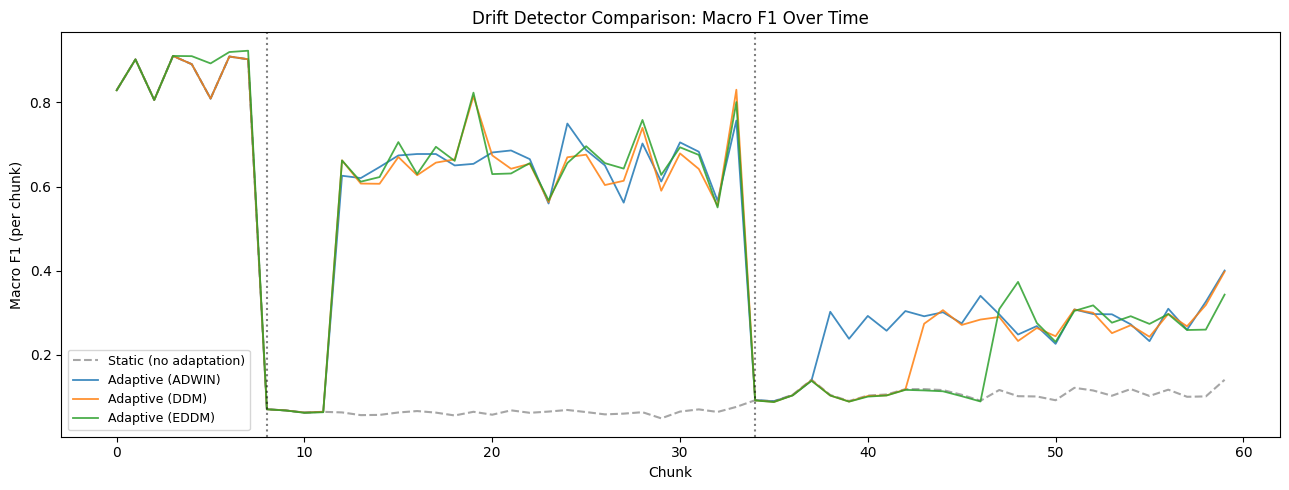

Saved plot to ../results/drift_detector_comparison.png


In [9]:
colors = {'ADWIN': 'tab:blue', 'DDM': 'tab:orange', 'EDDM': 'tab:green'}
fig, ax = plt.subplots(figsize=(13, 5))

static_f1s_ref = results['ADWIN']['static_f1s']
ax.plot(results['ADWIN']['chunk_ids'], static_f1s_ref, label='Static (no adaptation)',
        color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for name in detector_factories:
    r = results[name]
    ax.plot(r['chunk_ids'], r['adaptive_f1s'], label=f'Adaptive ({name})', color=colors[name], linewidth=1.3, alpha=0.85)

for pb in results['ADWIN']['phase_boundaries'][1:]:
    ax.axvline(pb, color='black', linestyle=':', alpha=0.5)

ax.set_xlabel('Chunk')
ax.set_ylabel('Macro F1 (per chunk)')
ax.set_title('Drift Detector Comparison: Macro F1 Over Time')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('../results/drift_detector_comparison.png', dpi=150)
plt.show()
print('Saved plot to ../results/drift_detector_comparison.png')

## 8. Drift/Retrain Timing

Phase boundaries occur at the chunk indices where Phase 2 and Phase 3 begin (marked with dotted lines above). A detector that reacts quickly to drift should trigger its first post-boundary retrain soon after each boundary; a detector that reacts slowly, or not at all, lags far behind or misses it.

In [10]:
phase_boundaries = results['ADWIN']['phase_boundaries']  # identical across runs (same data/order)

def lag_to_next_boundary(event_chunk, boundaries):
    upcoming = [b for b in boundaries if b <= event_chunk]
    return event_chunk - upcoming[-1] if upcoming else None

timing_rows = []
for name in detector_factories:
    r = results[name]
    n_drift, n_retrain = len(r['drift_events']), len(r['retrain_events'])
    first_after_p2 = next((c for c in r['retrain_events'] if c >= phase_boundaries[1]), None)
    first_after_p3 = next((c for c in r['retrain_events'] if c >= phase_boundaries[2]), None)
    lag_p2 = (first_after_p2 - phase_boundaries[1]) if first_after_p2 is not None else None
    lag_p3 = (first_after_p3 - phase_boundaries[2]) if first_after_p3 is not None else None
    total_retrain_time = sum(r['retrain_times'])
    timing_rows.append({
        'detector': name, 'n_drift_signals': n_drift, 'n_retrains': n_retrain,
        'chunks_to_retrain_after_phase2_start': lag_p2,
        'chunks_to_retrain_after_phase3_start': lag_p3,
        'mean_adaptive_macro_f1': round(float(np.mean(r['adaptive_f1s'])), 4),
        'mean_adaptive_fpr': round(float(np.nanmean(r['adaptive_fprs'])), 4),
        'total_retrain_seconds': round(total_retrain_time, 4),
        'mean_seconds_per_retrain': round(total_retrain_time / n_retrain, 4) if n_retrain else None,
    })

timing_df = pd.DataFrame(timing_rows)
timing_df

,detector,n_drift_signals,n_retrains,chunks_to_retrain_after_phase2_start,chunks_to_retrain_after_phase3_start,mean_adaptive_macro_f1,mean_adaptive_fpr,total_retrain_seconds,mean_seconds_per_retrain
0,ADWIN,4,4,3,3,0.4747,0.0341,0.2909,0.0727
1,DDM,2,2,3,8,0.4571,0.0275,0.1580,0.0790
2,EDDM,5,5,3,12,0.4529,0.0375,0.3440,0.0688


## 9. Final Holdout Evaluation Per Detector

Each detector's final adaptive model, evaluated on the same held-out data (never streamed or used for retraining) used in `adaptive_ids_adwin.ipynb`.

In [11]:
def holdout_macro_f1(model, df_holdout):
    X_h = df_holdout[feature_cols].values
    y_h = encoder.transform(df_holdout['Label'])
    y_pred = model.predict(X_h)
    labels = sorted(set(y_h))
    return f1_score(y_h, y_pred, labels=labels, average='macro', zero_division=0)

def holdout_fpr(model, df_holdout):
    X_h = df_holdout[feature_cols].values
    y_h = encoder.transform(df_holdout['Label'])
    y_pred = model.predict(X_h)
    return chunk_fpr(y_h, y_pred)

holdout_rows = []
for name in detector_factories:
    model = results[name]['final_model']
    holdout_rows.append({
        'detector': name,
        'phase1_holdout_macro_f1': round(holdout_macro_f1(model, df_phase1_holdout), 4),
        'phase2_holdout_macro_f1': round(holdout_macro_f1(model, df_phase2_holdout), 4),
        'phase3_holdout_macro_f1': round(holdout_macro_f1(model, df_phase3_holdout), 4),
        'phase1_holdout_fpr': round(holdout_fpr(model, df_phase1_holdout), 4),
        'phase2_holdout_fpr': round(holdout_fpr(model, df_phase2_holdout), 4),
        'phase3_holdout_fpr': round(holdout_fpr(model, df_phase3_holdout), 4),
    })
static_holdout = {
    'detector': 'Static (no adaptation)',
    'phase1_holdout_macro_f1': round(holdout_macro_f1(static_model, df_phase1_holdout), 4),
    'phase2_holdout_macro_f1': round(holdout_macro_f1(static_model, df_phase2_holdout), 4),
    'phase3_holdout_macro_f1': round(holdout_macro_f1(static_model, df_phase3_holdout), 4),
    'phase1_holdout_fpr': round(holdout_fpr(static_model, df_phase1_holdout), 4),
    'phase2_holdout_fpr': round(holdout_fpr(static_model, df_phase2_holdout), 4),
    'phase3_holdout_fpr': round(holdout_fpr(static_model, df_phase3_holdout), 4),
}
holdout_rows.append(static_holdout)
holdout_df = pd.DataFrame(holdout_rows)
holdout_df

,detector,phase1_holdout_macro_f1,phase2_holdout_macro_f1,phase3_holdout_macro_f1,phase1_holdout_fpr,phase2_holdout_fpr,phase3_holdout_fpr
0,ADWIN,0.6726,0.4945,0.2945,0.0411,0.0102,0.0308
1,DDM,0.6870,0.5345,0.2932,0.0274,0.0051,0.0223
2,EDDM,0.6876,0.4965,0.2382,0.0411,0.0051,0.0216
3,Static (no adaptation),0.7985,0.0591,0.0918,0.0000,0.0000,0.0020


## 9b. Classification Reports & Confusion Matrices Per Detector

Full precision/recall/F1/accuracy breakdown (via `classification_report`) and a row-normalized confusion matrix for each detector's final adaptive model, plus the static baseline, evaluated on the combined held-out data (all three phases, never streamed or used for retraining).


=== ADWIN — Combined Holdout Classification Report ===
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.00      0.00      0.00         4
                 BENIGN       0.82      0.97      0.89      1798
       BROWSERHIJACKING       0.00      0.00      0.00         8
       COMMANDINJECTION       0.50      0.43      0.46         7
 DDOS-ACK_FRAGMENTATION       0.85      1.00      0.92        17
        DDOS-HTTP_FLOOD       0.00      0.00      0.00         2
        DDOS-ICMP_FLOOD       1.00      1.00      1.00       475
DDOS-ICMP_FRAGMENTATION       0.83      0.97      0.89        30
      DDOS-PSHACK_FLOOD       0.99      0.98      0.99       257
       DDOS-RSTFINFLOOD       1.00      1.00      1.00       260
         DDOS-SLOWLORIS       0.00      0.00      0.00         2
DDOS-SYNONYMOUSIP_FLOOD       0.37      0.43      0.40       222
         DDOS-SYN_FLOOD       0.37      0.26      0.30       256
         DDOS-TCP_FLOOD       0.4

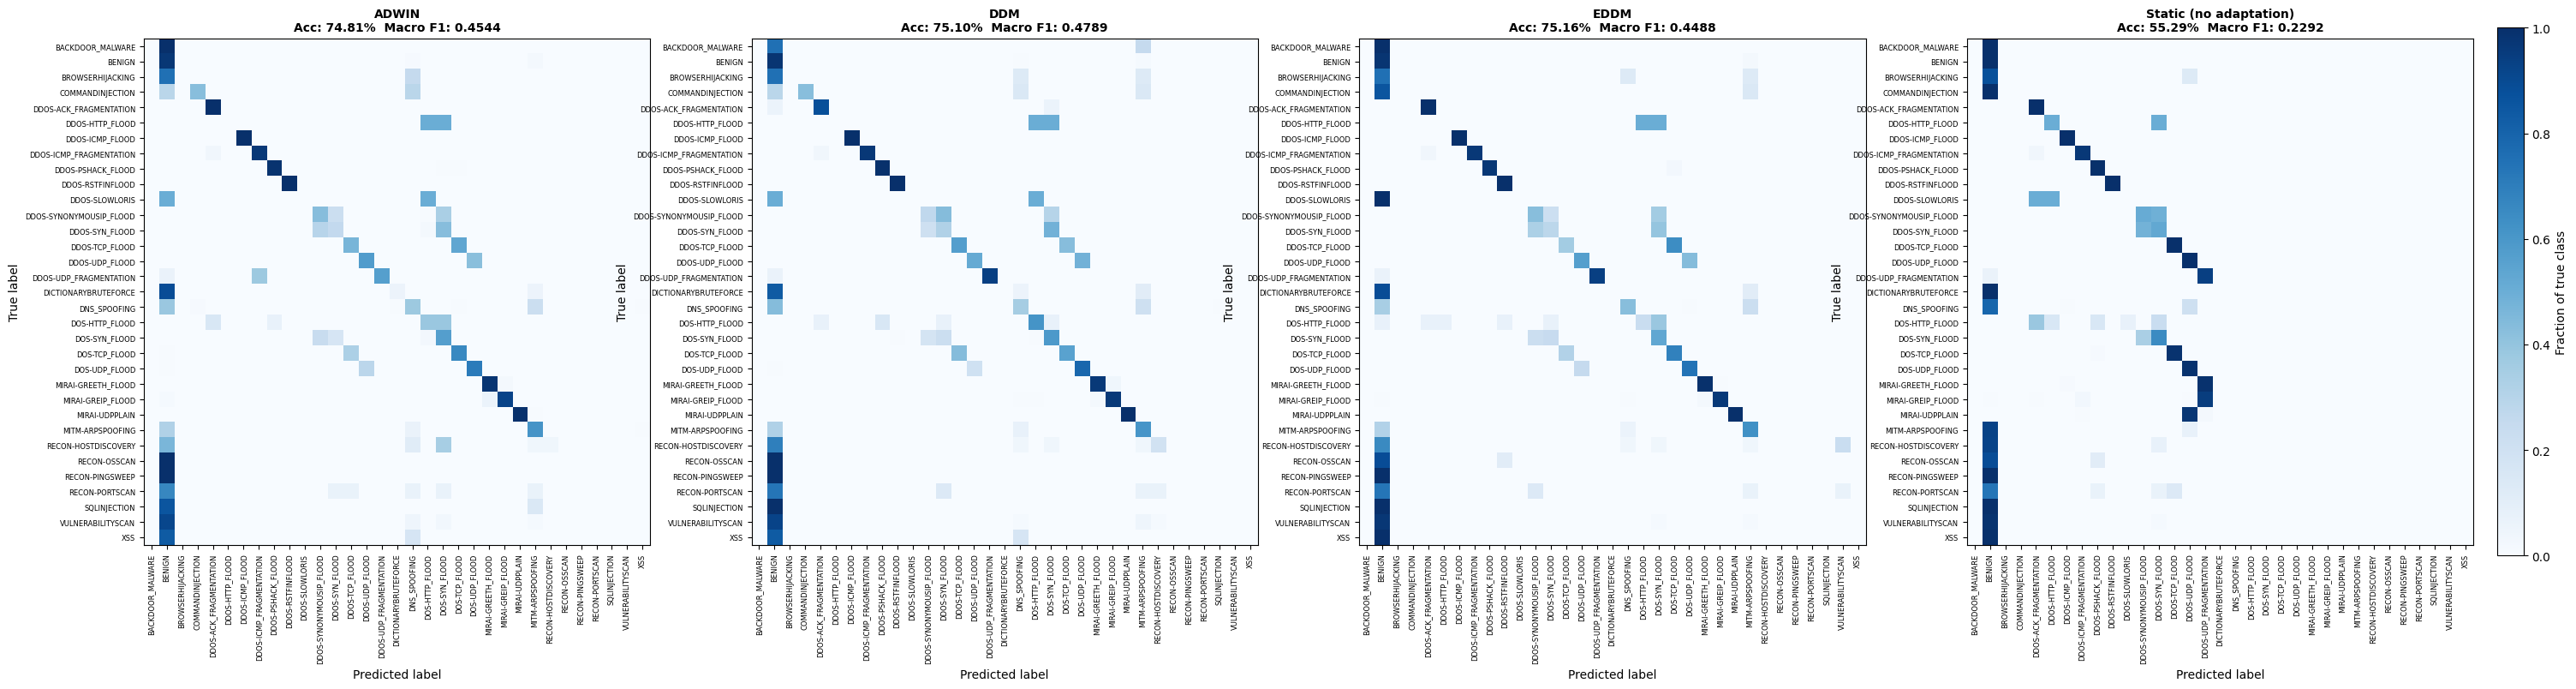

Saved ../results/drift_detector_confusion_matrices.png


In [12]:
from sklearn.metrics import confusion_matrix

df_holdout_all = pd.concat([df_phase1_holdout, df_phase2_holdout, df_phase3_holdout], ignore_index=True)
X_hold_all = df_holdout_all[feature_cols].values
y_hold_all = encoder.transform(df_holdout_all['Label'])
present_labels_all = sorted(set(y_hold_all))
present_names_all  = encoder.classes_[present_labels_all]

models_to_eval = {name: results[name]['final_model'] for name in detector_factories}
models_to_eval['Static (no adaptation)'] = static_model

fig, axes = plt.subplots(1, len(models_to_eval), figsize=(9 * len(models_to_eval), 8))
for ax, (name, model) in zip(axes, models_to_eval.items()):
    y_pred = model.predict(X_hold_all)
    print(f'\n=== {name} — Combined Holdout Classification Report ===')
    print(classification_report(y_hold_all, y_pred, labels=present_labels_all,
                                target_names=present_names_all, zero_division=0))

    cm = confusion_matrix(y_hold_all, y_pred, labels=present_labels_all, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(present_names_all)))
    ax.set_yticks(range(len(present_names_all)))
    ax.set_xticklabels(present_names_all, rotation=90, fontsize=6)
    ax.set_yticklabels(present_names_all, fontsize=6)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    acc = accuracy_score(y_hold_all, y_pred)
    macro_f1 = f1_score(y_hold_all, y_pred, labels=present_labels_all, average='macro', zero_division=0)
    ax.set_title(f'{name}\nAcc: {acc*100:.2f}%  Macro F1: {macro_f1:.4f}', fontweight='bold', fontsize=10)

fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01, label='Fraction of true class')
plt.savefig('../results/drift_detector_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved ../results/drift_detector_confusion_matrices.png')

## 10. Save Results

In [13]:
timing_df.to_csv('../results/drift_detector_timing.csv', index=False)
holdout_df.to_csv('../results/drift_detector_holdout_f1.csv', index=False)

per_chunk_rows = []
for name in detector_factories:
    r = results[name]
    for cid, sacc, aacc, sf1, af1 in zip(r['chunk_ids'], r['static_accs'], r['adaptive_accs'], r['static_f1s'], r['adaptive_f1s']):
        per_chunk_rows.append({'detector': name, 'chunk_id': cid, 'static_acc': sacc, 'adaptive_acc': aacc,
                               'static_macro_f1': sf1, 'adaptive_macro_f1': af1})
per_chunk_df = pd.DataFrame(per_chunk_rows)
per_chunk_df.to_csv('../results/drift_detector_per_chunk.csv', index=False)

print('Saved:')
print('  ../results/drift_detector_comparison.png')
print('  ../results/drift_detector_timing.csv')
print('  ../results/drift_detector_holdout_f1.csv')
print('  ../results/drift_detector_per_chunk.csv')

Saved:
  ../results/drift_detector_comparison.png
  ../results/drift_detector_timing.csv
  ../results/drift_detector_holdout_f1.csv
  ../results/drift_detector_per_chunk.csv
